In [1]:
#@title **MONTAR EL DRIVE** { display-mode: "form" }
import os
from google.colab import drive

path_ai = "ProyectoAI1" #@param {type:"string"}
path = "/content/drive/My Drive/" + path_ai
drive.mount('/content/drive')
os.chdir(path)
print(os.getcwd())

Mounted at /content/drive
/content/drive/My Drive/ProyectoAI1


In [7]:
##==========================================================================
#Este bloque tiene la matriz de caracteristicas, toca hacer muchas cosas
#=========================================================================

import os
import torch
import pandas as pd
from PIL import Image
from torchvision import models, transforms
from tqdm import tqdm


# 1. Configuración del modelo (ResNet50)
# Cargamos el modelo y eliminamos la última capa (clasificación)
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
modules = list(resnet.children())[:-1]  # Quitamos la capa 'fc'
feature_extractor = torch.nn.Sequential(*modules)
feature_extractor.eval()

# 2. Preprocesamiento de imágenes (Requerido por ResNet)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 3. Procesamiento de las carpetas
base_path = '/content/drive/MyDrive/ProyectoAI1/data'
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
modules = list(resnet.children())[:-1]
feature_extractor = torch.nn.Sequential(*modules)
feature_extractor.eval()

# Mover a GPU si está disponible (Colab ofrece GPU gratuita)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor.to(device)

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
# 3. Procesamiento de Imágenes y Extracción
categories = ['plastic', 'paper', 'glass']
data_records = []

with torch.no_grad():
    for category in categories:
        folder_path = os.path.join(base_path, category)

        if not os.path.exists(folder_path):
            print(f" Advertencia: No se encontró la carpeta {folder_path}")
            continue

        print(f" Procesando categoría: {category}")
        filenames = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for img_name in tqdm(filenames):
            img_path = os.path.join(folder_path, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                input_tensor = preprocess(img).unsqueeze(0).to(device)

                # Extraer features
                features = feature_extractor(input_tensor).flatten().cpu().numpy()

                # Guardar info básica y features
                record = {'label': category, 'image_name': img_name}
                # Usamos un diccionario para las features y luego actualizamos el record
                feat_dict = {f'feat_{i}': val for i, val in enumerate(features)}
                record.update(feat_dict)

                data_records.append(record)
            except Exception as e:
                print(f"❌ Error en {img_name}: {e}")

# 4. Crear el DataFrame final
df = pd.DataFrame(data_records)
print(f"\n✅ DataFrame creado. Forma: {df.shape}")

 Procesando categoría: plastic


100%|██████████| 482/482 [00:11<00:00, 40.88it/s]


 Procesando categoría: paper


100%|██████████| 594/594 [00:10<00:00, 55.79it/s]


 Procesando categoría: glass


100%|██████████| 501/501 [00:07<00:00, 64.94it/s]



✅ DataFrame creado. Forma: (1577, 2050)


In [8]:
df.head(10)

,label,image_name,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_2038,feat_2039,feat_2040,feat_2041,feat_2042,feat_2043,feat_2044,feat_2045,feat_2046,feat_2047
0,plastic,plastic331.jpg,0.000000,0.085200,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.002468,0.096812,0.000000,0.000000,0.014988,0.147035,0.000000,0.014789,0.000000,0.022817
1,plastic,plastic362.jpg,0.020129,0.291373,0.074844,0.000000,0.010495,0.0,0.000000,0.003083,...,0.000000,0.047719,0.000000,0.000000,0.000000,0.164317,0.029368,0.025523,0.000000,0.000000
2,plastic,plastic368.jpg,0.000000,0.055806,0.000000,0.000000,0.000000,0.0,0.200475,0.000000,...,0.000000,0.390765,0.153474,0.005100,0.000000,0.904534,0.000000,0.000000,0.000000,0.034995
3,plastic,plastic365.jpg,0.032518,0.316921,0.006349,0.020262,0.007159,0.0,0.000000,0.000000,...,0.000000,0.132400,0.918399,0.000000,0.106099,0.302785,0.000000,0.000000,0.000000,0.000000
4,plastic,plastic359.jpg,0.170614,0.217649,0.037085,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.112736,0.038744,0.081438,0.000000,0.055845,0.000000,0.000073,0.000000,0.008685
5,plastic,plastic344.jpg,0.059294,0.394018,0.076989,0.000000,0.083417,0.0,0.069939,0.000000,...,0.012237,0.335178,0.060042,0.010400,0.056974,1.217324,0.000000,0.013178,0.000000,0.054099
6,plastic,plastic370.jpg,0.083171,0.110004,0.023150,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.212399,0.410312,0.000000,0.234520,0.057433,0.000000,0.000000,0.000000,0.058155
7,plastic,plastic373.jpg,0.106882,0.306348,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.149106,0.023921,0.000000,0.000000,0.077194,0.000000,0.000000,0.000000,0.000000
8,plastic,plastic340.jpg,0.114454,0.227550,0.294217,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.272413,0.902527,0.010919,0.000000,0.205390,0.000000,0.013609,0.005194,0.001290
9,plastic,plastic378.jpg,0.000000,0.000000,0.083709,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.047529,0.000000,0.000000,0.000000,0.626444,0.000000,0.000000,0.000000,0.000000


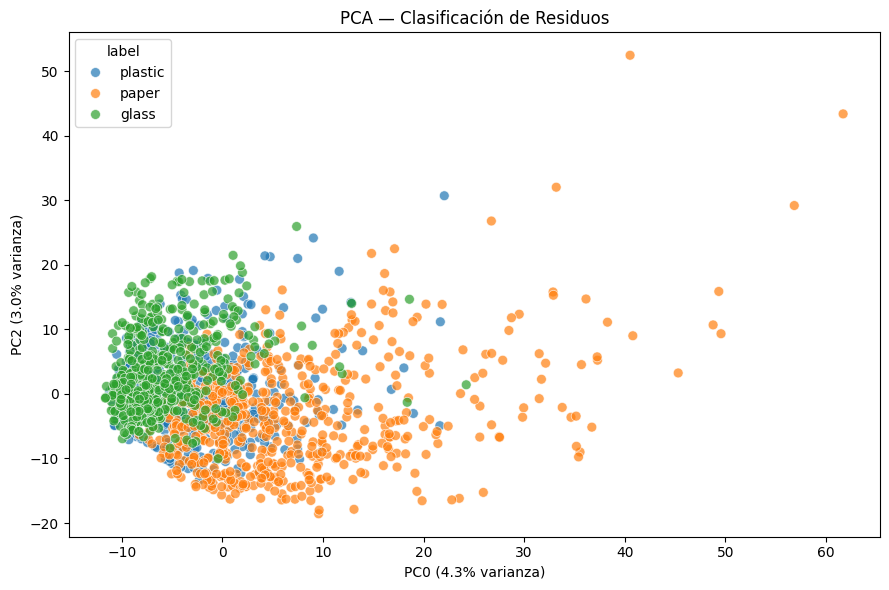


Reporte de Clasificación:
              precision    recall  f1-score   support

       glass       0.90      0.95      0.93       100
       paper       0.98      0.99      0.99       119
     plastic       0.93      0.88      0.90        97

    accuracy                           0.94       316
   macro avg       0.94      0.94      0.94       316
weighted avg       0.94      0.94      0.94       316



/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning:

Liblinear failed to converge, increase the number of iterations.



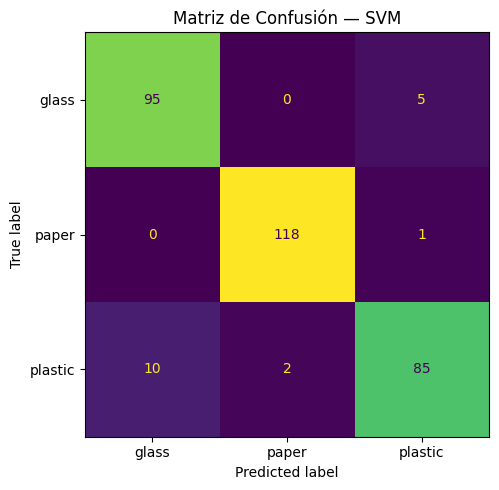

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = [f'feat_{i}' for i in range(2048)]
X_scaled = StandardScaler().fit_transform(df[feature_cols].values)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100

df_pca = pd.DataFrame({'PC0': X_pca[:, 0], 'PC2': X_pca[:, 1], 'label': df['label'].values})

plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x='PC0', y='PC2', hue='label', alpha=0.7, s=50)
plt.xlabel(f'PC0 ({var1:.1f}% varianza)')
plt.ylabel(f'PC2 ({var2:.1f}% varianza)')
plt.title('PCA — Clasificación de Residuos')
plt.tight_layout()
plt.show()

# 7. Entrenamiento del clasificador (SVM)
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

clf = LinearSVC(max_iter=2000, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# 8. Evaluación del modelo
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
plt.title('Matriz de Confusión — SVM')
plt.tight_layout()
plt.show()

In [15]:

import os
import torch
import pandas as pd
import numpy as np
import cv2
from PIL import Image
from torchvision import models, transforms
from sklearn.decomposition import PCA
from tqdm import tqdm
from google.colab import drive
from scipy.stats import skew, kurtosis  # <--- IMPORTANTE: Faltaba esto

# 1. Configuración Inicial
drive.mount('/content/drive')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar Modelo
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
feature_extractor = torch.nn.Sequential(*(list(resnet.children())[:-1])).to(device).eval()

# Transformación para ResNet
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

base_path = '/content/drive/MyDrive/ProyectoAI1/data'

# 2. Función de Humanización Mejorada
def get_advanced_human_features(img_pil):
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w, _ = img_bgr.shape

    feats = {}

    # Estadísticas de Color
    for i, col in enumerate(['blue', 'green', 'red']):
        channel = img_bgr[:,:,i].flatten()
        feats[f'{col}_mean'] = np.mean(channel)
        feats[f'{col}_std'] = np.std(channel)
        feats[f'{col}_skew'] = skew(channel)
        feats[f'{col}_kurt'] = kurtosis(channel)

    # Espacio HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    feats['hue_mean'], feats['sat_mean'], feats['val_mean'] = np.mean(hsv[:,:,0]), np.mean(hsv[:,:,1]), np.mean(hsv[:,:,2])

    # Momentos de Hu (Forma)
    moments = cv2.moments(img_gray)
    hu = cv2.HuMoments(moments).flatten()
    for i in range(7):
        feats[f'hu_{i}'] = -np.sign(hu[i]) * np.log10(np.abs(hu[i]) + 1e-10)

    # Textura y Bordes
    edges = cv2.Canny(img_gray, 100, 200)
    feats['edge_density'] = np.sum(edges) / (h * w)
    feats['rms_contrast'] = np.std(img_gray)
    feats['sharpness'] = cv2.Laplacian(img_gray, cv2.CV_64F).var()

    # Histogramas (Bins)
    for i, col in enumerate(['b', 'g', 'r']):
        hist = cv2.calcHist([img_bgr], [i], None, [4], [0, 256]).flatten()
        for j in range(4): feats[f'hist_{col}_{j}'] = hist[j]

    return feats

# 3. Proceso de Extracción
categories = ['metal', 'paper', 'glass']
all_data, resnet_vectors = [], []

with torch.no_grad():
    for cat in categories:
        folder = os.path.join(base_path, cat)
        if not os.path.exists(folder):
            print(f"⚠️ Carpeta no encontrada: {folder}")
            continue

        print(f"Procesando {cat}...")
        valid_files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        for img_name in tqdm(valid_files):
            path = os.path.join(folder, img_name)
            try:
                img_pil = Image.open(path).convert('RGB')

                # Human + ResNet
                all_data.append({**get_advanced_human_features(img_pil), 'label': cat, 'name': img_name})

                tensor = preprocess(img_pil).unsqueeze(0).to(device)
                resnet_vectors.append(feature_extractor(tensor).flatten().cpu().numpy())
            except Exception as e:
                print(f"Error en {img_name}: {e}")

df_main = pd.DataFrame(all_data)

# 4. PCA y DataFrame Final (Con validación de datos vacíos)
if len(resnet_vectors) > 0:
    # Convertir a array para el PCA
    X_resnet = np.array(resnet_vectors)

    pca = PCA(n_components=min(3, X_resnet.shape[0]))
    pca_features = pca.fit_transform(X_resnet)

    df_pca = pd.DataFrame(pca_features, columns=[f'pca_resnet_{i}' for i in range(pca_features.shape[1])])

    df_final = pd.concat([
        pd.DataFrame(all_data),
        pd.DataFrame(pca_features, columns=[f'pca_resnet_{i}' for i in range(pca_features.shape[1])])
    ], axis=1)

    print("\n✅ Proceso exitoso.")
    print(df_main.head())

    # Guardar automáticamente en tu Drive
    df_final.to_csv(os.path.join(base_path, 'dataset_estructurado.csv'), index=False)
else:
    print("❌ No se procesaron imágenes. Revisa tus carpetas en Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Procesando metal...


100%|██████████| 410/410 [00:20<00:00, 20.00it/s]


Procesando paper...


100%|██████████| 594/594 [00:27<00:00, 21.61it/s]


Procesando glass...


100%|██████████| 501/501 [00:22<00:00, 21.90it/s]



✅ Proceso exitoso.
    blue_mean   blue_std  blue_skew  blue_kurt  green_mean  green_std  \
0  191.470393  60.025822  -1.183436   0.039149  197.000509  55.370079   
1  172.995127  50.508580  -1.056724   0.598060  177.672572  50.554774   
2  143.958125  62.847865  -0.294219  -1.182490  150.972834  64.239808   
3  174.059347  45.244311  -1.193782   1.003548  163.973490  41.711207   
4  155.851659  42.539720  -1.084501   0.874493  164.973302  42.983308   

   green_skew  green_kurt    red_mean    red_std  ...  hist_g_3  hist_r_0  \
0   -1.156608    0.065636  203.454753  44.246946  ...  138388.0    1634.0   
1   -0.881665   -0.103324  182.043889  52.460947  ...  103839.0    5196.0   
2   -0.294087   -1.197592  161.440659  59.792404  ...   70383.0    8164.0   
3   -1.021988    0.989184  161.369461  41.786957  ...   63165.0    9270.0   
4   -0.952003    0.450578  171.829376  48.716755  ...   74288.0    6521.0   

   hist_r_1  hist_r_2  hist_r_3  label          name  pca_resnet_0  \
0   1266

,blue_mean,blue_std,blue_skew,blue_kurt,green_mean,green_std,green_skew,green_kurt,red_mean,red_std,...,hist_g_0,hist_g_1,hist_g_2,hist_g_3,hist_r_0,hist_r_1,hist_r_2,hist_r_3,label,name
0,191.470393,60.025822,-1.183436,0.039149,197.000509,55.370079,-1.156608,0.065636,203.454753,44.246946,...,2597.0,30661.0,24962.0,138388.0,1634.0,12660.0,42198.0,140116.0,metal,metal1.jpg
1,172.995127,50.508580,-1.056724,0.598060,177.672572,50.554774,-0.881665,-0.103324,182.043889,52.460947,...,6477.0,32054.0,54238.0,103839.0,5196.0,31201.0,53307.0,106904.0,metal,metal150.jpg
2,143.958125,62.847865,-0.294219,-1.182490,150.972834,64.239808,-0.294087,-1.197592,161.440659,59.792404,...,19646.0,54306.0,52273.0,70383.0,8164.0,56506.0,59876.0,72062.0,metal,metal153.jpg
3,174.059347,45.244311,-1.193782,1.003548,163.973490,41.711207,-1.021988,0.989184,161.369461,41.786957,...,6466.0,22372.0,104605.0,63165.0,9270.0,21017.0,114109.0,52212.0,metal,metal136.jpg
4,155.851659,42.539720,-1.084501,0.874493,164.973302,42.983308,-0.952003,0.450578,171.829376,48.716755,...,5888.0,31777.0,84655.0,74288.0,6521.0,27204.0,70640.0,92243.0,metal,metal122.jpg
5,182.370132,54.791979,-2.019032,3.382575,186.000778,44.693492,-1.834978,3.168344,187.260381,40.818852,...,6683.0,14122.0,55640.0,120163.0,3944.0,15412.0,57987.0,119265.0,metal,metal124.jpg
6,118.353582,41.359990,-0.750155,0.363590,140.241175,43.178939,-0.868694,0.426400,159.215281,45.440664,...,18888.0,32352.0,115859.0,29509.0,11194.0,28714.0,116163.0,40537.0,metal,metal117.jpg
7,170.432765,31.317294,-1.304942,1.841813,185.137029,29.122303,-1.383287,2.123476,196.087886,30.002013,...,423.0,9509.0,79001.0,107675.0,75.0,7275.0,70740.0,118518.0,metal,metal17.jpg
8,130.072128,44.253139,0.236509,-0.455505,139.758392,41.264818,0.108301,-0.303508,148.871338,37.643279,...,5504.0,71445.0,88406.0,31253.0,2198.0,48490.0,111567.0,34353.0,metal,metal171.jpg
9,170.995270,40.436819,-1.570067,2.380046,172.541484,43.700107,-1.722321,2.663177,173.391947,45.220137,...,9120.0,17351.0,96697.0,73440.0,7801.0,17536.0,94216.0,77055.0,metal,metal102.jpg


In [18]:

print(df_final.head())

    blue_mean   blue_std  blue_skew  blue_kurt  green_mean  green_std  \
0  191.470393  60.025822  -1.183436   0.039149  197.000509  55.370079   
1  172.995127  50.508580  -1.056724   0.598060  177.672572  50.554774   
2  143.958125  62.847865  -0.294219  -1.182490  150.972834  64.239808   
3  174.059347  45.244311  -1.193782   1.003548  163.973490  41.711207   
4  155.851659  42.539720  -1.084501   0.874493  164.973302  42.983308   

   green_skew  green_kurt    red_mean    red_std  ...  hist_g_3  hist_r_0  \
0   -1.156608    0.065636  203.454753  44.246946  ...  138388.0    1634.0   
1   -0.881665   -0.103324  182.043889  52.460947  ...  103839.0    5196.0   
2   -0.294087   -1.197592  161.440659  59.792404  ...   70383.0    8164.0   
3   -1.021988    0.989184  161.369461  41.786957  ...   63165.0    9270.0   
4   -0.952003    0.450578  171.829376  48.716755  ...   74288.0    6521.0   

   hist_r_1  hist_r_2  hist_r_3  label          name  pca_resnet_0  \
0   12660.0   42198.0  14011

In [37]:
df_final.head(10)

,blue_mean,blue_std,blue_skew,blue_kurt,green_mean,green_std,green_skew,green_kurt,red_mean,red_std,...,hist_r_0,hist_r_1,hist_r_2,hist_r_3,label,name,pca_resnet_0,pca_resnet_1,pca_resnet_2,label_num
0,191.470393,60.025822,-1.183436,0.039149,197.000509,55.370079,-1.156608,0.065636,203.454753,44.246946,...,1634.0,12660.0,42198.0,140116.0,metal,metal1.jpg,-3.035275,4.024006,-1.442141,1
1,172.995127,50.508580,-1.056724,0.598060,177.672572,50.554774,-0.881665,-0.103324,182.043889,52.460947,...,5196.0,31201.0,53307.0,106904.0,metal,metal150.jpg,0.394614,1.373441,-2.002192,1
2,143.958125,62.847865,-0.294219,-1.182490,150.972834,64.239808,-0.294087,-1.197592,161.440659,59.792404,...,8164.0,56506.0,59876.0,72062.0,metal,metal153.jpg,-0.255601,1.060242,-2.283986,1
3,174.059347,45.244311,-1.193782,1.003548,163.973490,41.711207,-1.021988,0.989184,161.369461,41.786957,...,9270.0,21017.0,114109.0,52212.0,metal,metal136.jpg,-3.369418,-0.700560,-2.003844,1
4,155.851659,42.539720,-1.084501,0.874493,164.973302,42.983308,-0.952003,0.450578,171.829376,48.716755,...,6521.0,27204.0,70640.0,92243.0,metal,metal122.jpg,-0.399060,-3.699590,-0.251959,1
5,182.370132,54.791979,-2.019032,3.382575,186.000778,44.693492,-1.834978,3.168344,187.260381,40.818852,...,3944.0,15412.0,57987.0,119265.0,metal,metal124.jpg,-3.623239,0.146766,1.111196,1
6,118.353582,41.359990,-0.750155,0.363590,140.241175,43.178939,-0.868694,0.426400,159.215281,45.440664,...,11194.0,28714.0,116163.0,40537.0,metal,metal117.jpg,-0.786339,-1.632751,0.855813,1
7,170.432765,31.317294,-1.304942,1.841813,185.137029,29.122303,-1.383287,2.123476,196.087886,30.002013,...,75.0,7275.0,70740.0,118518.0,metal,metal17.jpg,-3.691572,-1.037882,3.875278,1
8,130.072128,44.253139,0.236509,-0.455505,139.758392,41.264818,0.108301,-0.303508,148.871338,37.643279,...,2198.0,48490.0,111567.0,34353.0,metal,metal171.jpg,-2.281431,-2.970299,2.084947,1
9,170.995270,40.436819,-1.570067,2.380046,172.541484,43.700107,-1.722321,2.663177,173.391947,45.220137,...,7801.0,17536.0,94216.0,77055.0,metal,metal102.jpg,2.006103,-1.246279,-1.517527,1


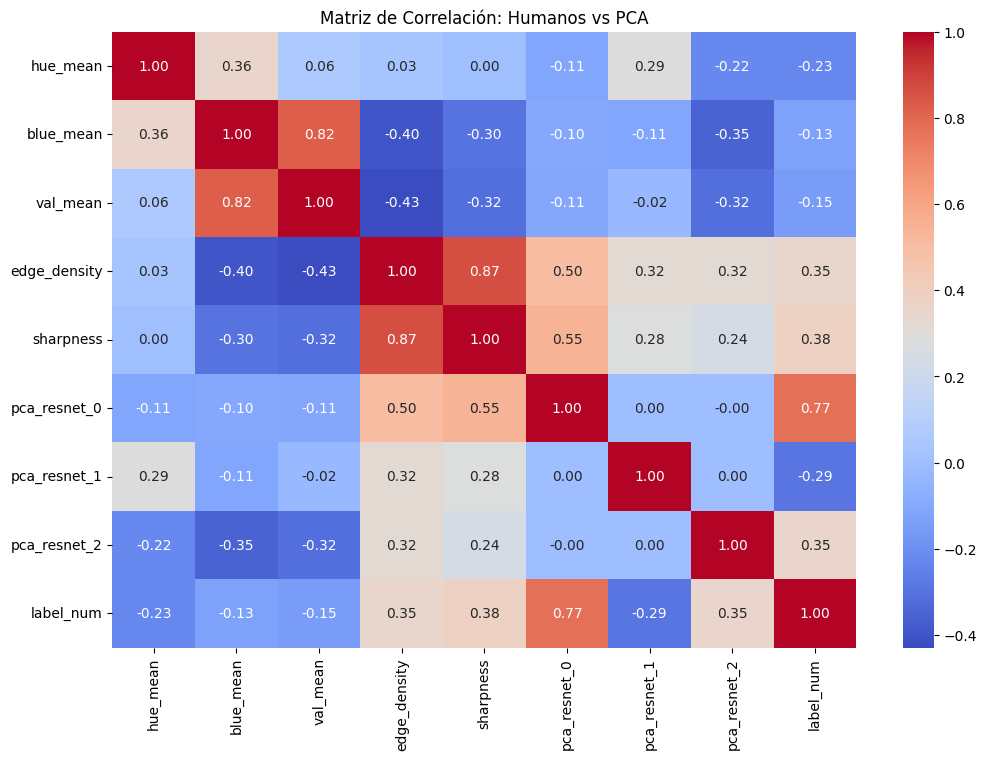

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Codificar la etiqueta para que sea numérica
df_final['label_num'] = df_final['label'].astype('category').cat.codes

# 2. Seleccionar una mezcla de columnas para el mapa de calor
# Tomamos las humanas más importantes y los componentes PCA
cols_interes = ['hue_mean', 'blue_mean', 'val_mean', 'edge_density', 'sharpness',
                'pca_resnet_0', 'pca_resnet_1','pca_resnet_2', 'label_num']

plt.figure(figsize=(12, 8))
sns.heatmap(df_final[cols_interes].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación: Humanos vs PCA")
plt.show()

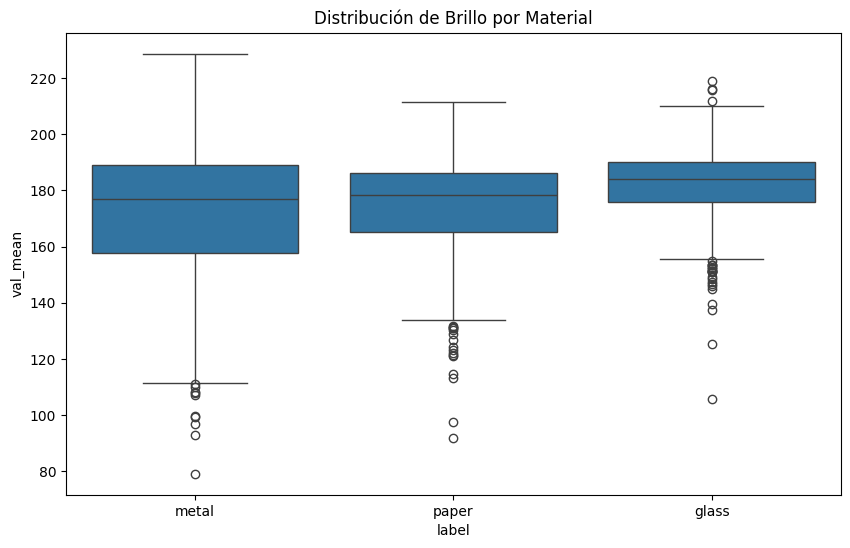

In [20]:
# Comparar el Brillo (val_mean) entre categorías
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='val_mean', data=df_final)
plt.title("Distribución de Brillo por Material")
plt.show()

In [30]:
import plotly.express as px

fig = px.scatter_3d(df_final, x='pca_resnet_0', y='pca_resnet_2', z='val_mean',
                    color='label', title="Separación de Materiales: PCA + Brillo")
fig.show()

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la correlación solo en columnas numéricas

corr_full = df_final.corr(numeric_only=True)

# 2. ¿Qué variables humanas explican el PCA_0 de la ResNet?
# Buscamos las que tengan valores más cercanos a 1 o -1
top_correlations0 = corr_full['pca_resnet_0'].sort_values(ascending=False)

print(" Variables que 'explican' el comportamiento de la IA (PCA_0):")
print(top_correlations0.head(10)) # Correlación positiva (van de la mano)
print("\n" + "-"*30)
print(top_correlations0.tail(5))  # Correlación negativa (son opuestas)

# . ¿Qué variables humanas explican el PCA_1 de la ResNet?
top_correlations2 = corr_full['pca_resnet_2'].sort_values(ascending=False)

print(" Variables que 'explican' el comportamiento de la IA (PCA_2):")
print(top_correlations2.head(10)) # Correlación positiva (van de la mano)
print("\n" + "-"*30)
print(top_correlations2.tail(5))  # Correlación negativa (son opuestas)


 Variables que 'explican' el comportamiento de la IA (PCA_0):
pca_resnet_0    1.000000
label_num       0.773226
sharpness       0.546900
edge_density    0.503531
blue_skew       0.233422
green_skew      0.195650
green_std       0.137794
red_skew        0.127898
hist_g_1        0.122573
rms_contrast    0.108635
Name: pca_resnet_0, dtype: float64

------------------------------
val_mean     -0.109628
hue_mean     -0.112967
red_kurt     -0.131863
green_kurt   -0.182265
blue_kurt    -0.182782
Name: pca_resnet_0, dtype: float64
 Variables que 'explican' el comportamiento de la IA (PCA_2):
pca_resnet_2    1.000000
label_num       0.352974
edge_density    0.319300
blue_skew       0.305273
hist_r_1        0.300072
hist_g_1        0.299342
green_skew      0.287700
hist_b_0        0.274068
red_skew        0.248329
sharpness       0.243499
Name: pca_resnet_2, dtype: float64

------------------------------
hu_1         -0.288803
green_mean   -0.314733
hu_0         -0.315559
val_mean     -0.316402


/tmp/ipykernel_673/1923556896.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_673/1923556896.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_673/1923556896.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_673/1923556896.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




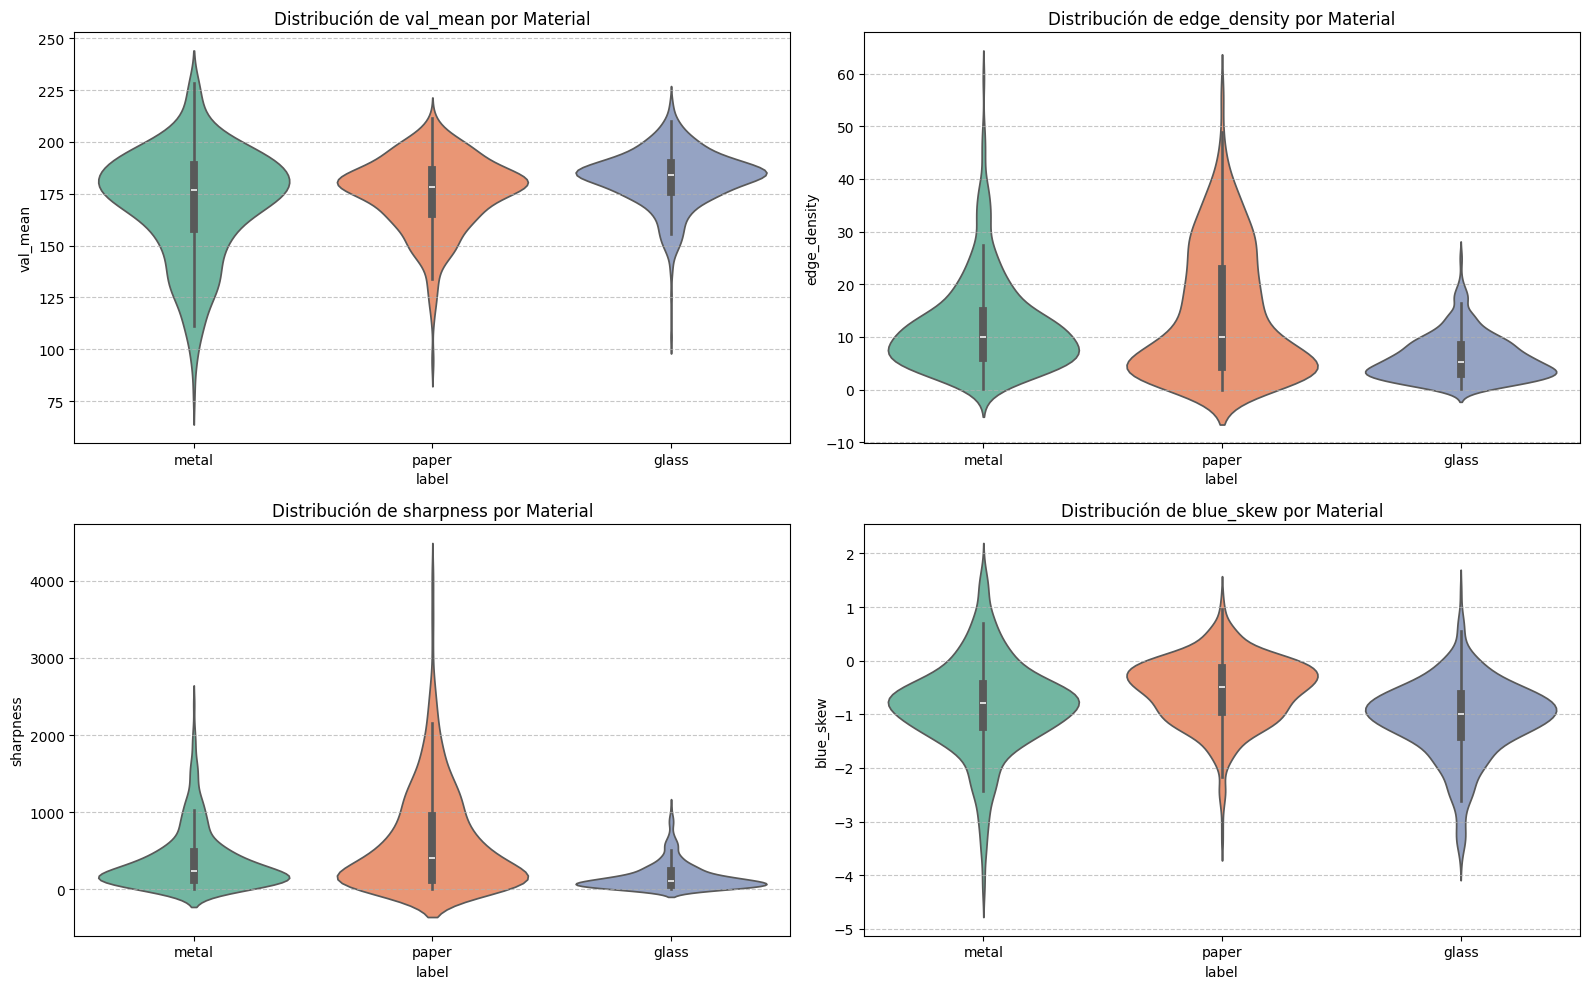

In [35]:
# Definimos las variables que sospechamos son clave
features_clave = ['val_mean', 'edge_density', 'sharpness', 'blue_skew']

plt.figure(figsize=(16, 10))

for i, feature in enumerate(features_clave):
    plt.subplot(2, 2, i+1)
    sns.violinplot(x='label', y=feature, data=df_final, palette='Set2')
    plt.title(f'Distribución de {feature} por Material')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()